In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import netCDF4 as nc
from scipy.stats import linregress

import sys
sys.path.append('/home/z5297792/UNSW-MRes/MRes/SEACOFS_dataset') 
from clim_functions import phys_grad, compute_core_mean, add_region_column, plot_region_map


In [2]:
fname = f'/srv/scratch/z3533156/26year_BRAN2020/outer_avg_01461.nc'
dataset = nc.Dataset(fname)
lon_rho = np.transpose(dataset.variables['lon_rho'], axes=(1, 0))
lat_rho = np.transpose(dataset.variables['lat_rho'], axes=(1, 0))
mask_rho = np.transpose(dataset.variables['mask_rho'], axes=(1, 0))
h = np.transpose(dataset.variables['h'], axes=(1, 0))
# f = np.transpose(dataset.variables['f'], axes=(1, 0))
angle = dataset.variables['angle'][0, 0]
z_r = np.load('/srv/scratch/z5297792/z_r.npy')
z_r = np.transpose(z_r, (1, 2, 0))
def distance(lat1, lon1, lat2, lon2):
    EARTH_RADIUS = 6357
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat, dlon = lat2 - lat1, lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return EARTH_RADIUS * 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
j_mid, i_mid = lon_rho.shape[1] // 2, lon_rho.shape[0] // 2
dx = distance(lat_rho[:-1, j_mid], lon_rho[:-1, j_mid],
              lat_rho[1:, j_mid], lon_rho[1:, j_mid])
dy = distance(lat_rho[i_mid, :-1], lon_rho[i_mid, :-1],
              lat_rho[i_mid, 1:], lon_rho[i_mid, 1:])
x_grid = np.insert(np.cumsum(dx), 0, 0)
y_grid = np.insert(np.cumsum(dy), 0, 0)
X_grid, Y_grid = np.meshgrid(x_grid, y_grid, indexing='ij')

levels_lat = [-40, -35, -30, -25]
levels_lon = [150, 155, 160]


In [3]:
# df_eddies = pd.read_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/DOPPIO_SEACOFS_26yr_50m_vert_check/df_eddies_50m_vert_checked_processed.pkl')
df_eddies = pd.read_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/df_eddies_beta_data.pkl')
# df_tilt = pd.read_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/DOPPIO_SEACOFS_26yr_50m_vert_check/df_tilt_vert_checked.pkl')
# df_eddies = df_eddies.merge(
#     df_tilt[['Eddy', 'Day', 'TiltDis', 'TiltDir']],
#     how='left',
#     left_on=['Eddy', 'Day'],
#     right_on=['Eddy', 'Day']
# )
df_eddies = add_region_column(
    df_eddies,
    X_grid, Y_grid,
    lon_rho, lat_rho,
    h, mask_rho
)
df_AE = df_eddies[df_eddies.Cyc=='AE'].copy().dropna()
df_CE = df_eddies[df_eddies.Cyc=='CE'].copy().dropna()
df_eddies


,Eddy,Day,Cyc,lon,lat,ic,jc,xc,yc,w,...,plan_beta,topo_beta_y,topo_beta_x,PV_grad_y,PV_grad_x,PV_grad_mag,beta,topo_beta_mag,plan_beta_mag,Region
0,1,1462,CE,161.072036,-29.736582,261,274,928.181752,1356.070550,-0.000016,...,NaN,NaN,NaN,NaN,NaN,NaN,-2.008069e-11,NaN,NaN,U2
1,1,1463,CE,160.982386,-29.745743,260,274,920.121471,1352.093925,-0.000014,...,NaN,NaN,NaN,NaN,NaN,NaN,-2.008439e-11,NaN,NaN,U2
2,1,1464,CE,160.892701,-29.754904,258,273,912.061191,1348.117301,-0.000012,...,NaN,NaN,NaN,NaN,NaN,NaN,-2.008362e-11,NaN,NaN,U2
3,1,1465,CE,160.929437,-29.612368,258,276,911.162024,1364.461638,-0.000019,...,-1.343844e-14,-6.317108e-14,1.072004e-13,-7.660952e-14,1.072004e-13,1.317609e-13,-2.010812e-11,1.244287e-13,1.343844e-14,U2
4,1,1466,CE,160.908986,-29.586156,258,277,908.463829,1366.554462,-0.000019,...,-1.327453e-14,-6.773640e-14,1.096381e-13,-8.101093e-14,1.096381e-13,1.363205e-13,-2.011627e-11,1.288748e-13,1.327453e-14,U2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125221,2929,10646,CE,153.739453,-37.488262,181,61,515.983450,302.961328,-0.000026,...,-4.035147e-15,-2.013442e-15,4.021675e-15,-6.048589e-15,4.021675e-15,7.263560e-15,-1.841270e-11,4.497535e-15,4.035147e-15,D1
125222,2929,10647,CE,153.687115,-37.523299,181,60,512.684226,297.695084,-0.000027,...,-4.028653e-15,-9.607917e-16,3.766445e-15,-4.989445e-15,3.766445e-15,6.251453e-15,-1.840257e-11,3.887059e-15,4.028653e-15,D1
125223,2929,10648,CE,153.699708,-37.537452,181,60,514.199660,296.590511,-0.000021,...,NaN,NaN,NaN,NaN,NaN,NaN,-1.840257e-11,NaN,NaN,D1
125224,2929,10649,CE,153.682657,-37.451789,180,62,510.019363,305.068558,-0.000019,...,NaN,NaN,NaN,NaN,NaN,NaN,-1.842593e-11,NaN,NaN,D1


Starting from

$$
PV = \frac{\omega + f}{h},
$$

and neglecting gradients in relative vorticity,

$$
\nabla PV \approx
\left(
\frac{\partial PV}{\partial x},
\frac{\partial PV}{\partial y}
\right).
$$

Since $f=f(y)$,

$$
\frac{\partial PV}{\partial x}
=
-\frac{f}{h^2}\frac{\partial h}{\partial x},
$$

and

$$
\frac{\partial PV}{\partial y}
=
\frac{1}{h}\frac{\partial f}{\partial y}
-\frac{f}{h^2}\frac{\partial h}{\partial y}
=
\frac{\beta}{h}
-\frac{f}{h^2}\frac{\partial h}{\partial y}.
$$

Thus the horizontal PV gradient becomes

$$
\nabla PV
=
\left(
-\frac{f}{h^2}\frac{\partial h}{\partial x},
\;
\frac{\beta}{h}
-\frac{f}{h^2}\frac{\partial h}{\partial y}
\right).
$$

The magnitude of the PV gradient is then

$$
|\nabla PV|
=
\sqrt{
\left(\frac{\partial PV}{\partial x}\right)^2
+
\left(\frac{\partial PV}{\partial y}\right)^2
}.
$$

This provides a scalar measure of the total large-scale PV gradient experienced by an eddy.

The direction (bearing) of the PV gradient may also be useful:

$$
\theta_{PV}
=
\tan^{-1}
\left(
\frac{\partial PV/\partial y}
     {\partial PV/\partial x}
\right).
$$

This allows direct comparison between the eddy tilt direction and the direction of the ambient PV gradient through

$$
\Delta \theta
=
\theta_{\rm tilt}
-
\theta_{PV}.
$$

Such a diagnostic may be particularly useful over the continental slope, where cross-shelf bathymetric gradients can rotate the PV gradient away from the purely meridional direction associated with planetary $\beta$.


In [4]:
# --------------------------------------------------
# Bathymetry and Coriolis
# --------------------------------------------------
h = np.transpose(dataset.variables['h'], axes=(1, 0))
f = np.transpose(dataset.variables['f'], axes=(1, 0))

# df_eddies = compute_core_mean(
#     df_eddies, X_grid, Y_grid, mask_rho,
#     fixed_field=h,
#     colname="h"
# )

# df_eddies['f'] = f[df_eddies.ic, df_eddies.jc]

# --------------------------------------------------
# Potential vorticity magnitude
# PV = (omega + f) / h
# --------------------------------------------------
# df_eddies['PV'] = (df_eddies['w'] + df_eddies['f']) / df_eddies['h']
# df_eddies['PV_mag'] = np.abs(df_eddies['PV'])

# --------------------------------------------------
# Potential-vorticity gradient components
# --------------------------------------------------
dfdx, dfdy = phys_grad(f, X_grid*1e3, Y_grid*1e3, mask_rho)
dhdx, dhdy = phys_grad(h, X_grid*1e3, Y_grid*1e3, mask_rho)

df_dN = -(np.sin(angle) * dfdx + np.cos(angle) * dfdy)

dh_dN = -(np.sin(angle) * dhdx + np.cos(angle) * dhdy)
dh_dE = -(np.cos(angle) * dhdx - np.sin(angle) * dhdy)

beta = df_dN
plan_beta = df_dN / h
topo_beta_y = -f / h**2 * dh_dN
topo_beta_x = -f / h**2 * dh_dE

plan_beta = np.abs(plan_beta)
topo_beta_mag= np.hypot(topo_beta_x, topo_beta_y)

PV_grad_y = plan_beta + topo_beta_y
PV_grad_x = topo_beta_x
PV_grad_mag = np.hypot(PV_grad_x, PV_grad_y)

log_ratio = np.log10(plan_beta / topo_beta_mag)
log_ratio[~np.isfinite(log_ratio)] = np.nan

# df_eddies['beta'] = df_dN[df_eddies.ic, df_eddies.jc]

# df_eddies = compute_core_mean(
#     df_eddies, X_grid, Y_grid, mask_rho,
#     fixed_field=plan_beta,
#     colname="plan_beta"
# )

# df_eddies = compute_core_mean(
#     df_eddies, X_grid, Y_grid, mask_rho,
#     fixed_field=topo_beta_y,
#     colname="topo_beta_y"
# )

# df_eddies = compute_core_mean(
#     df_eddies, X_grid, Y_grid, mask_rho,
#     fixed_field=topo_beta_x,
#     colname="topo_beta_x"
# )

# df_eddies['PV_grad_y'] = df_eddies['plan_beta'] + df_eddies['topo_beta_y']  
# df_eddies['PV_grad_x'] = df_eddies['topo_beta_x']

# df_eddies['PV_grad_mag'] = np.hypot(
#     df_eddies['PV_grad_x'],
#     df_eddies['PV_grad_y']
# )

# df_eddies['topo_beta_mag'] = np.hypot(
#     df_eddies['topo_beta_x'],
#     df_eddies['topo_beta_y']
# )

# df_eddies['plan_beta_mag'] = df_eddies['plan_beta'].abs()

# df_eddies = compute_core_mean(
#     df_eddies, X_grid, Y_grid, mask_rho,
#     fixed_field=log_ratio,
#     colname="beta_ratio"
# )


In [5]:
def panel(df_eddies, xcol, xlabel, legend_key, ax=None, xlim=None, split=None,
          reg_lo_override=None, reg_hi_override=None, scatter=False,
          xlim_flag=False, styles=None, linfit=False, xp=(10,90)):

    if ax is None:
        fig, ax = plt.subplots()

    df_eddies = df_eddies.copy()

    # Convert masked arrays to normal arrays with NaNs
    df_eddies[xcol] = np.ma.filled(np.ma.asarray(df_eddies[xcol]), np.nan)
    df_eddies['TiltDis'] = np.ma.filled(np.ma.asarray(df_eddies['TiltDis']), np.nan)

    if styles is None:
        styles = {
            'AE': {'line': 'darkred', 'fill': 'red'},
            'CE': {'line': 'navy',    'fill': 'blue'}
        }

    df_all = df_eddies.dropna(subset=[xcol])
    x = df_all[xcol].to_numpy(dtype=float)
    x_min, x_max = np.nanmin(x), np.nanmax(x)

    nbins = min(30, max(8, int(np.sqrt(len(x)))))
    bins = np.unique(np.nanquantile(x, np.linspace(0, 1, nbins + 1)))

    if len(bins) < 3:
        bins = np.linspace(x_min, x_max, 9)

    bin_centers = 0.5 * (bins[:-1] + bins[1:])

    for cyc in ['AE', 'CE']:
        dfm = df_eddies[df_eddies.Cyc == cyc].dropna(subset=[xcol, 'TiltDis'])

        xval = dfm[xcol].to_numpy(dtype=float)
        tilt = dfm['TiltDis'].to_numpy(dtype=float)

        mask = np.isfinite(xval) & np.isfinite(tilt)
        xval, tilt = xval[mask], tilt[mask]

        mask = (xval >= x_min) & (xval <= x_max)
        xval, tilt = xval[mask], tilt[mask]

        d = np.digitize(xval, bins)

        med = np.array([
            np.nanmedian(tilt[d == i]) if np.any(d == i) else np.nan
            for i in range(1, len(bins))
        ])
        q25 = np.array([
            np.nanquantile(tilt[d == i], 0.25) if np.any(d == i) else np.nan
            for i in range(1, len(bins))
        ])
        q75 = np.array([
            np.nanquantile(tilt[d == i], 0.75) if np.any(d == i) else np.nan
            for i in range(1, len(bins))
        ])

        if scatter:
            ax.scatter(xval, tilt, s=1, alpha=0.08, color=styles[cyc]['fill'])

        msk = np.isfinite(med)

        ax.plot(
            bin_centers[msk], med[msk],
            lw=3,
            color=styles[cyc]['line'],
            alpha=.6
        )

        ax.fill_between(
            bin_centers[msk],
            q25[msk],
            q75[msk],
            color=styles[cyc]['fill'],
            alpha=0.10
        )
        if linfit:
            if split is None:
                lo, hi = np.nanpercentile(xval, [10, 90])
                reg_mask = (xval >= lo) & (xval <= hi)
    
                if reg_mask.sum() > 2:
                    m, c, *_ = linregress(xval[reg_mask], tilt[reg_mask])
                    xf = np.linspace(lo, hi, 200)
    
                    ax.plot(
                        xf, m * xf + c,
                        '--',
                        lw=3,
                        color=styles[cyc]['fill'],
                        label=fr'{cyc}: TD={m:.3g} {legend_key} {"$-$" if c < 0 else "$+$"} {abs(c):.3g}'
                    )
    
            else:
                lo, hi = np.nanpercentile(xval, [10, 90])
                hi2 = reg_hi_override if reg_hi_override is not None else hi
                lo2 = reg_lo_override if reg_lo_override is not None else lo
    
                for l, (a, b) in enumerate(zip([lo2, split], [split, hi2])):
                    reg_mask = (xval >= a) & (xval <= b)
    
                    if reg_mask.sum() > 2:
                        m, c, *_ = linregress(xval[reg_mask], tilt[reg_mask])
                        xf = np.linspace(a, b, 200)
    
                        ax.plot(
                            xf, m * xf + c,
                            ':' if l == 0 else '--',
                            lw=3,
                            color=styles[cyc]['fill'],
                            label=fr'{cyc}: TD={m:.3g} {legend_key} {"$-$" if c < 0 else "$+$"} {abs(c):.3g}'
                        )
            ax.legend(loc='upper right', ncol=2)

    if xlim is None:
        ax.set_xlim(*np.nanpercentile(df_eddies[xcol].to_numpy(dtype=float), [xp[0], xp[1]]))
        # ax.set_xlim(ax.get_xlim())
    else:
        ax.set_xlim(*xlim)

    if xlim_flag:
        ax.set_xlim(bin_centers.min(), bin_centers.max())


    ax.set_xlabel(xlabel)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    return ax
    

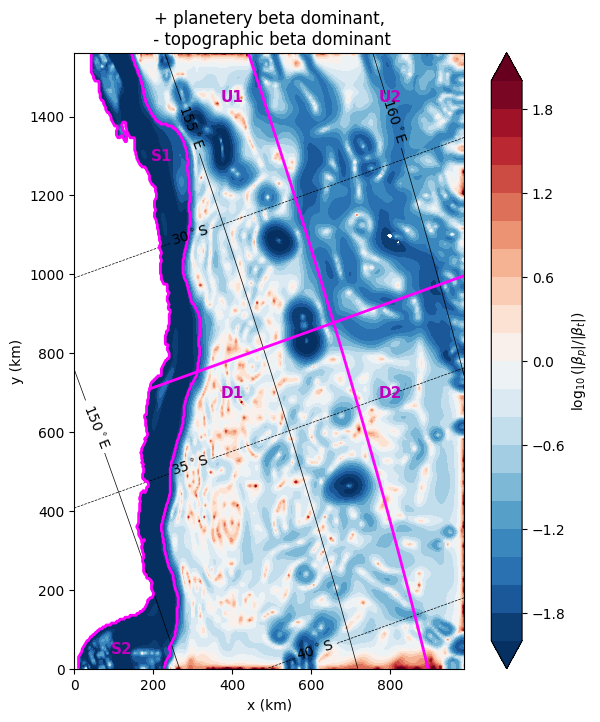

In [22]:
# --------------------------------------------------
# Planetary vs topographic dominance ratio
# --------------------------------------------------
df_eddies['beta_ratio'] = np.log10(
    df_eddies['plan_beta_mag'] / df_eddies['topo_beta_mag']
)
df_eddies.loc[~np.isfinite(df_eddies['beta_ratio']), 'beta_ratio'] = np.nan

fig, ax = plt.subplots(figsize=(7, 8), constrained_layout=False)

levels = np.linspace(-2, 2, 21)

m = ax.contourf(
    X_grid,
    Y_grid,
    log_ratio,
    levels=levels,
    cmap='RdBu_r',
    extend='both'
)

cbar = fig.colorbar(m, ax=ax)
cbar.set_label(r'$\log_{10}(|\beta_p|/|\beta_t|)$')

c1 = ax.contour(
    X_grid, Y_grid, lat_rho,
    levels=[-40, -35, -30, -25],
    colors='k',
    linewidths=0.5
)
ax.clabel(c1, fmt=lambda v: f"{abs(v):.0f}$^\\circ$S", inline=True)

c2 = ax.contour(
    X_grid, Y_grid, lon_rho,
    levels=[150, 155, 160],
    colors='k',
    linewidths=0.5
)
ax.clabel(c2, fmt=lambda v: f"{v:.0f}$^\\circ$E", inline=True)

plot_region_map(
    ax,
    X_grid,
    Y_grid,
    lon_rho,
    lat_rho,
    h,
    mask_rho,
    levels_lat,
    levels_lon,
    lon_split=157,
    lat_split=-33,
    title=None,
    borders_only=True
)

# ax.set_title(
#     r'Planetary vs topographic PV-gradient dominance'
#     '\n'
#     r'positive: $|\beta_p|>|\beta_t|$; negative: $|\beta_t|>|\beta_p|$'
# )
ax.set_title('+ planetery beta dominant,\n - topographic beta dominant')

ax.set_xlabel('x (km)')
ax.set_ylabel('y (km)')
ax.set_aspect('equal')

plt.show()

0 → equal planetary and topographic influence\
+1 → planetary is 10× stronger\
+2 → planetary is 100× stronger\
−1 → topographic is 10× stronger\
−2 → topographic is 100× stronger\


(0.0, 55.0)

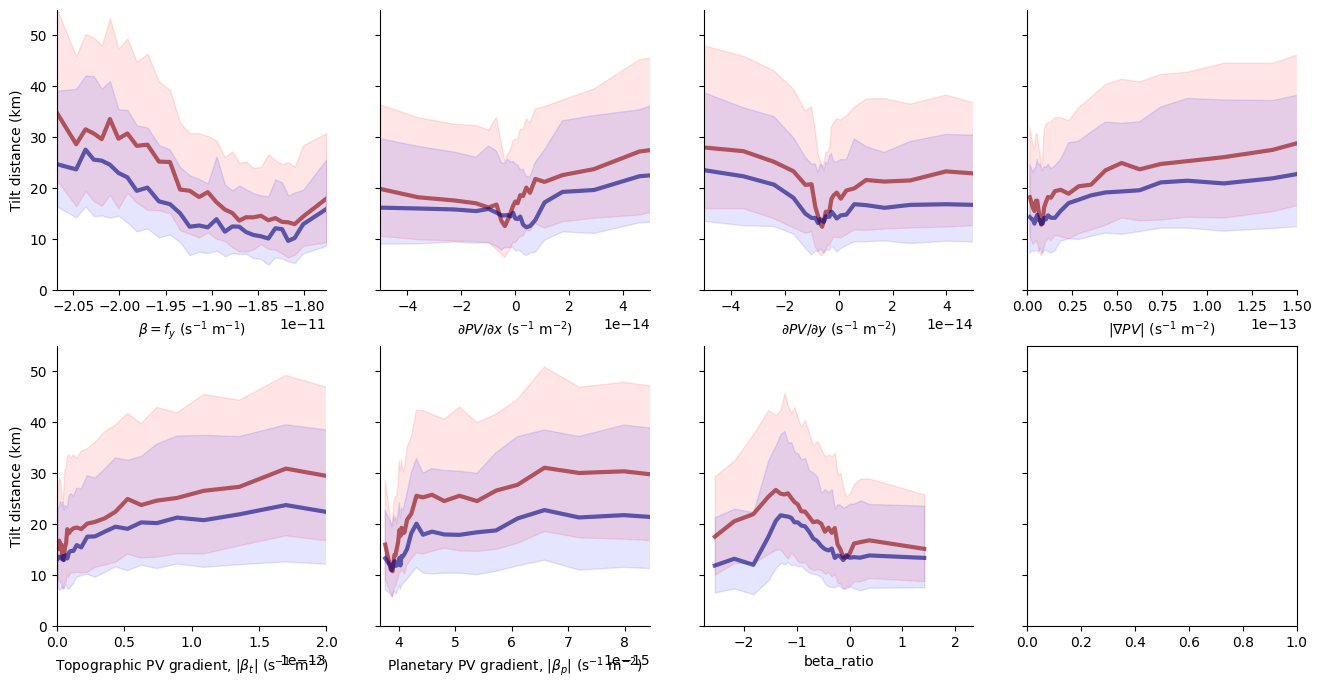

In [7]:
fig, axs = plt.subplots(2, 4, figsize=(16,8), sharey=True)
axs = axs.flatten()

xp = (5,95)

ax = axs[0]
panel(
    df_eddies,
    'beta',
    r'$\beta=f_y$ (s$^{-1}$ m$^{-1}$)',
    r'$\beta$',
    ax=ax,
    xlim_flag=True,
    scatter=False,
    xlim=(0,100)
    # xp=xp,
)
ax.set_ylabel('Tilt distance (km)')


ax = axs[1]
panel(
    df_eddies,
    'PV_grad_x',
    r'$\partial PV/\partial x$ (s$^{-1}$ m$^{-2}$)',
    r'$PV_x$',
    ax=ax,
    xlim_flag=False,
    scatter=False,
    linfit=False,
    # xp=(10,90)
    xlim=(-5e-14, 5e-14)
)


ax = axs[2]
panel(
    df_eddies,
    'PV_grad_y',
    r'$\partial PV/\partial y$ (s$^{-1}$ m$^{-2}$)',
    r'$PV_y$',
    ax=ax,
    xlim_flag=False,
    scatter=False,
    linfit=False,
    # xp=(10,90)
    xlim=(-5e-14, 5e-14)
)


ax = axs[3]
panel(
    df_eddies,
    'PV_grad_mag',
    r'$|\nabla PV|$ (s$^{-1}$ m$^{-2}$)',
    r'$|\nabla PV|$',
    ax=ax,
    xlim_flag=False,
    scatter=False,
    linfit=False,
    xlim=(0,1.5e-13)
    # xp=(0,90)
)


ax = axs[4]
panel(
    df_eddies,
    'topo_beta_mag',
    r'Topographic PV gradient, $|\beta_t|$ (s$^{-1}$ m$^{-2}$)',
    r'$|\beta_t|$',
    ax=ax,
    xlim_flag=False,
    scatter=False,
    linfit=False,
    xlim=(0,2e-13)
)
ax.set_ylabel('Tilt distance (km)')


ax = axs[5]
panel(
    df_eddies,
    'plan_beta_mag',
    r'Planetary PV gradient, $|\beta_p|$ (s$^{-1}$ m$^{-2}$)',
    r'$|\beta_p|$',
    ax=ax,
    xlim_flag=False,
    scatter=False,
    linfit=False,
    xp=(0,90)
)

ax = axs[6]
panel(
    df_eddies,
    'beta_ratio',
    r'beta_ratio',
    r'$|\beta_p|$',
    ax=ax,
    xlim_flag=False,
    scatter=False,
    linfit=False,
    xp=(0,100)
)

axs[0].set_ylim(0,55)
# plt.tight_layout()


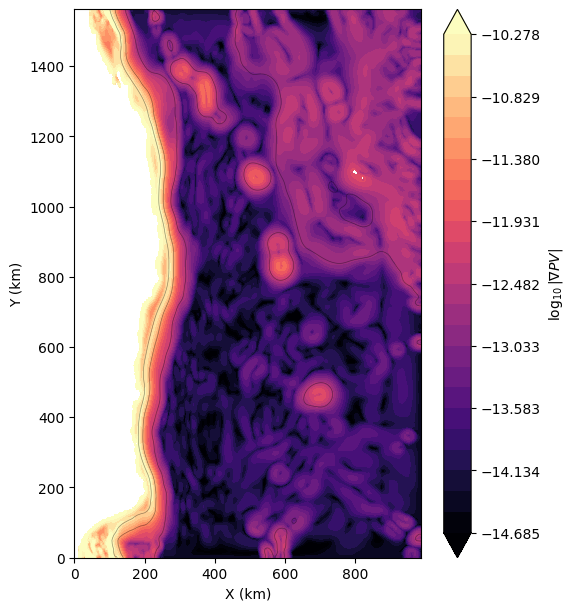

In [8]:
fig, ax = plt.subplots(figsize=(6, 6), constrained_layout=True)

PV = np.asarray(PV_grad_mag.filled(np.nan), dtype=float)

# log only valid positive values
PV_plot = np.full_like(PV, np.nan, dtype=float)
valid = np.isfinite(PV) & (PV > 0)
PV_plot[valid] = np.log10(PV[valid])

lo, hi = np.nanpercentile(PV_plot[valid], [2, 98])

# fallback if percentiles collapse
if (not np.isfinite(lo)) or (not np.isfinite(hi)) or (lo == hi):
    lo, hi = np.nanmin(PV_plot[valid]), np.nanmax(PV_plot[valid])

levels = np.linspace(lo, hi, 25)

m = ax.contourf(
    X_grid,
    Y_grid,
    PV_plot,
    levels=levels,
    cmap='magma',
    extend='both'
)

ax.contour(
    X_grid,
    Y_grid,
    h,
    levels=[200, 1000, 4000],
    colors='k',
    linewidths=0.5,
    alpha=0.4
)

cbar = fig.colorbar(m, ax=ax)
cbar.set_label(r'$\log_{10}|\nabla PV|$')

ax.set_aspect('equal')
ax.set_xlabel('X (km)')
ax.set_ylabel('Y (km)')
plt.show()


 #### PV gradient direction!

In [9]:
# --------------------------------------------------
# Direction of horizontal PV gradient over the domain
# --------------------------------------------------

PVx = topo_beta_x                  # dPV/dx, eastward component
PVy = plan_beta + topo_beta_y       # dPV/dy, northward component

# Standard mathematical angle: 0=east, 90=north
theta_math = np.degrees(np.arctan2(PVy, PVx))

# Convert to compass bearing: 0=north, 90=east
theta_PV = (90 - theta_math) % 360

# Mask invalid/land points
theta_PV = np.where(np.isfinite(PVx) & np.isfinite(PVy), theta_PV, np.nan)
theta_PV = np.where(mask_rho == 1, theta_PV, np.nan)


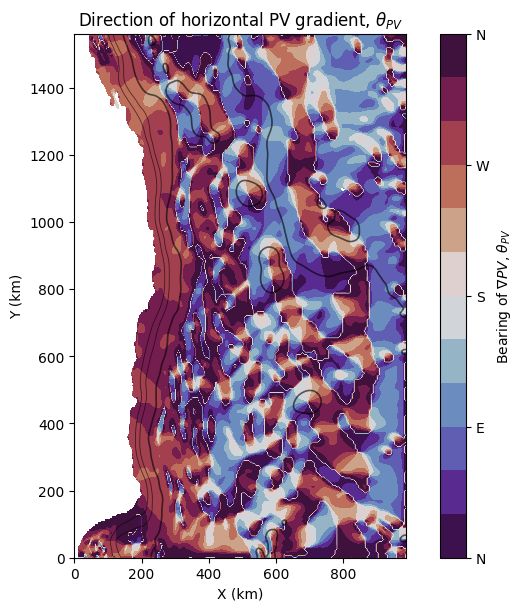

In [10]:
fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)

levels = np.arange(0, 361, 30)

m = ax.contourf(
    X_grid, Y_grid, theta_PV,
    levels=levels,
    cmap='twilight_shifted',
    extend='neither'
)

# Optional bathymetry contours
ax.contour(
    X_grid, Y_grid, h,
    levels=[200, 1000, 4000],
    colors='k',
    linewidths=[0.6, 0.6, 1.2],
    alpha=0.6
)

cbar = fig.colorbar(m, ax=ax)
cbar.set_label(r'Bearing of $\nabla PV$, $\theta_{PV}$')
cbar.set_ticks([0, 90, 180, 270, 360])
cbar.set_ticklabels(['N', 'E', 'S', 'W', 'N'])

ax.set_aspect('equal')
ax.set_xlabel('X (km)')
ax.set_ylabel('Y (km)')
ax.set_title(r'Direction of horizontal PV gradient, $\theta_{PV}$')

plt.show()

compare with tilt direction

In [11]:
# PV-gradient components already computed
PVx = df_eddies['PV_grad_x'].values
PVy = df_eddies['PV_grad_y'].values

# Direction of PV gradient in degrees
# This assumes PVx = eastward component, PVy = northward component
theta_PV = np.degrees(np.arctan2(PVy, PVx))

# Convert to bearing convention: 0 = north, 90 = east
theta_PV_bearing = (90 - theta_PV) % 360

df_eddies['theta_PV'] = theta_PV_bearing

# Angular difference wrapped to [-180, 180]
df_eddies['dtheta_PV'] = (
    (df_eddies['TiltDir'] - df_eddies['theta_PV'] + 180) % 360
) - 180

# Absolute angular difference [0, 180]
df_eddies['abs_dtheta_PV'] = np.abs(df_eddies['dtheta_PV'])


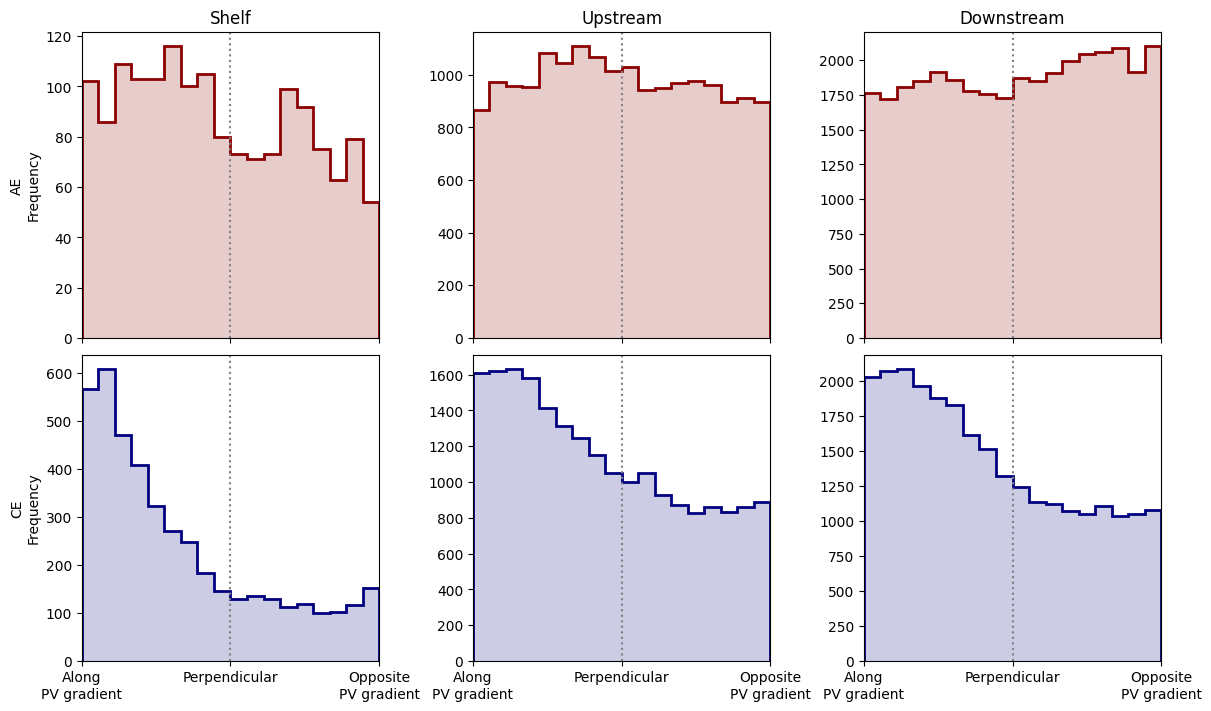

In [12]:
bins = np.arange(0, 181, 10)

fig, axs = plt.subplots(
    2, 3,
    figsize=(12, 7),
    sharex=True,
    # sharey=True,
    constrained_layout=True
)

regions = [
    ['S1', 'S2'],
    ['U1', 'U2'],
    ['D1', 'D2']
]

titles = ['Shelf', 'Upstream', 'Downstream']

for i, cyc in enumerate(['AE', 'CE']):

    for j, regs in enumerate(regions):

        ax = axs[i, j]

        df = df_eddies[
            (df_eddies.Cyc == cyc) &
            (df_eddies.Region.isin(regs))
        ]

        vals = df['abs_dtheta_PV'].dropna()

        color = 'darkred' if cyc == 'AE' else 'navy'

        ax.hist(
            vals,
            bins=bins,
            histtype='stepfilled',
            alpha=0.2,
            color=color
        )

        ax.hist(
            vals,
            bins=bins,
            histtype='step',
            linewidth=2,
            color=color
        )

        ax.axvline(90, color='grey', ls=':')

        if i == 0:
            ax.set_title(titles[j])

        if j == 0:
            ax.set_ylabel(f'{cyc}\nFrequency')

        ax.set_xlim(0, 180)

for ax in axs[-1]:
    ax.set_xticks([0, 90, 180])
    ax.set_xticklabels([
        'Along\nPV gradient',
        'Perpendicular',
        'Opposite\nPV gradient'
    ])

plt.show()


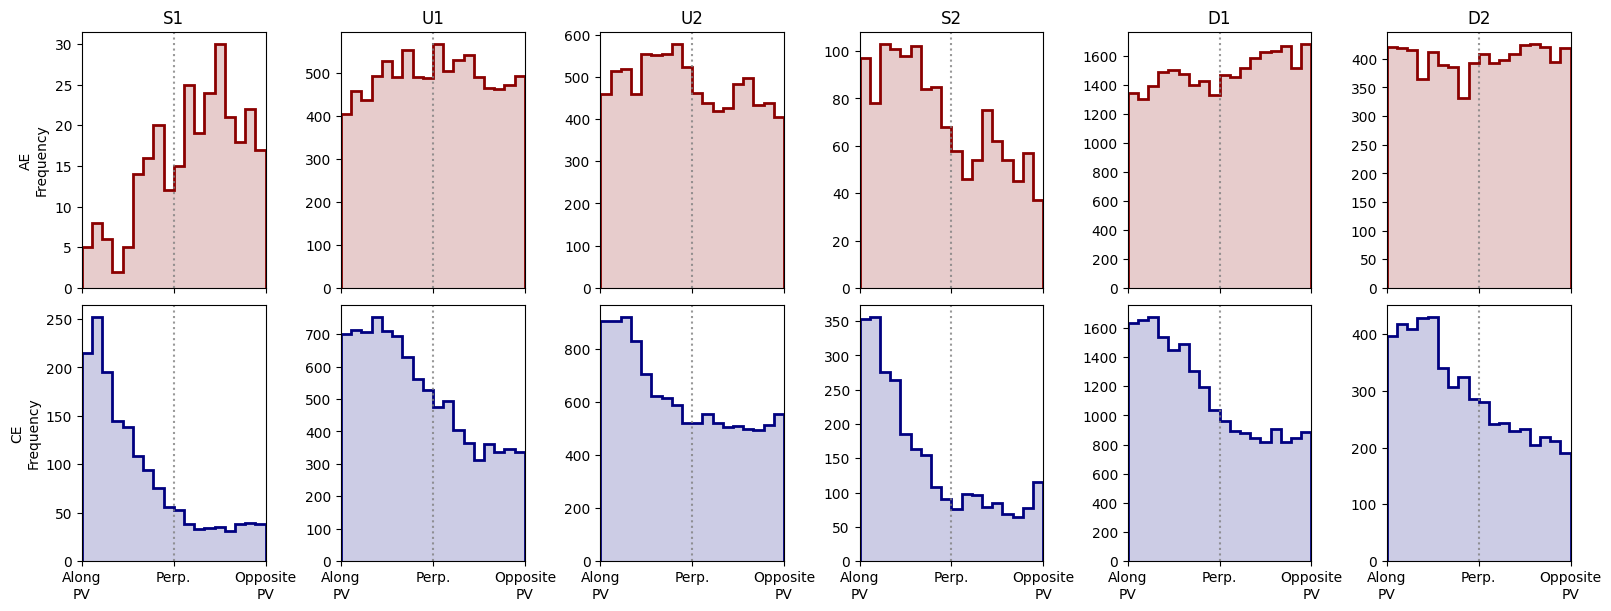

In [13]:
bins = np.arange(0, 181, 10)

fig, axs = plt.subplots(
    2, 6,
    figsize=(16, 6),
    sharex=True,
    # sharey=True,
    constrained_layout=True
)

region_order = ['S1', 'U1', 'U2', 'S2', 'D1', 'D2']

for i, cyc in enumerate(['AE', 'CE']):

    color = 'darkred' if cyc == 'AE' else 'navy'

    for j, region in enumerate(region_order):

        ax = axs[i, j]

        vals = df_eddies.loc[
            (df_eddies.Cyc == cyc) &
            (df_eddies.Region == region),
            'abs_dtheta_PV'
        ].dropna()

        ax.hist(
            vals,
            bins=bins,
            histtype='stepfilled',
            alpha=0.2,
            color=color
        )

        ax.hist(
            vals,
            bins=bins,
            histtype='step',
            linewidth=2,
            color=color
        )

        ax.axvline(90, color='grey', ls=':', alpha=0.8)

        # med = np.nanmedian(vals)
        # ax.axvline(
        #     med,
        #     color='k',
        #     lw=2,
        #     label=f'Median={med:.0f}$^\\circ$'
        # )

        if i == 0:
            ax.set_title(region)

        if j == 0:
            ax.set_ylabel(f'{cyc}\nFrequency')

        if i == 1:
            ax.set_xticks([0, 90, 180])
            ax.set_xticklabels([
                'Along\nPV',
                'Perp.',
                'Opposite\nPV'
            ])

        ax.set_xlim(0, 180)

plt.show()


In [14]:
# df_eddies.to_pickle('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/df_eddies_beta_data.pkl')
